In [1]:
import numpy as np
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, LongType, StringType, ArrayType
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import os


# In cluster use the HDFS path prefix
path_prefix = "hdfs:///projects/BDA-12/"
# In local use the local path prefix
# path_prefix = "../"

In [3]:
spark = SparkSession.builder.appName('IngredientClustering').getOrCreate()
ingredients_schema = StructType([
    StructField('fdc_id', LongType(), False),
    StructField('description', StringType(), True),
    StructField('all_ingredients', ArrayType(StringType()), True)
])
df = spark.read.schema(ingredients_schema).parquet(f'{path_prefix}/output/ingredients_nutrional_profiles')

In [4]:
from pyspark.sql.functions import explode, col, collect_list, lower, trim
df_exploded = df.select('fdc_id', 'description', explode('all_ingredients').alias('ingredient'))
ingredient_foods = df_exploded.withColumn('ingredient_clean', lower(trim(col('ingredient')))).groupBy('ingredient_clean').agg(collect_list('description').alias('foods'))

In [ ]:
ingredient_rows = ingredient_foods.collect()
ingredients = [r['ingredient_clean'] for r in ingredient_rows]
foods_lists = [r['foods'] for r in ingredient_rows]

26/01/15 15:50:08 ERROR TaskResultGetter: Exception while getting task result15]
java.lang.IllegalStateException: unread block data
	at java.base/java.io.ObjectInputStream$BlockDataInputStream.setBlockDataMode(ObjectInputStream.java:3033)
	at java.base/java.io.ObjectInputStream.readObject0(ObjectInputStream.java:1722)
	at java.base/java.io.ObjectInputStream.readArray(ObjectInputStream.java:2134)
	at java.base/java.io.ObjectInputStream.readObject0(ObjectInputStream.java:1675)
	at java.base/java.io.ObjectInputStream.readObject(ObjectInputStream.java:489)
	at java.base/java.io.ObjectInputStream.readObject(ObjectInputStream.java:447)
	at org.apache.spark.serializer.JavaDeserializationStream.readObject(JavaSerializer.scala:87)
	at org.apache.spark.serializer.SerializerHelper$.deserializeFromChunkedBuffer(SerializerHelper.scala:52)
	at org.apache.spark.scheduler.DirectTaskResult.value(TaskResult.scala:108)
	at org.apache.spark.scheduler.TaskResultGetter$$anon$3.$anonfun$run$1(TaskResultGette

Py4JJavaError: An error occurred while calling o78.collectToPython.
: org.apache.spark.SparkException: Job aborted due to stage failure: Exception while getting task result: java.lang.IllegalStateException: unread block data
	at org.apache.spark.scheduler.DAGScheduler.failJobAndIndependentStages(DAGScheduler.scala:2844)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$abortStage$2(DAGScheduler.scala:2780)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$abortStage$2$adapted(DAGScheduler.scala:2779)
	at scala.collection.mutable.ResizableArray.foreach(ResizableArray.scala:62)
	at scala.collection.mutable.ResizableArray.foreach$(ResizableArray.scala:55)
	at scala.collection.mutable.ArrayBuffer.foreach(ArrayBuffer.scala:49)
	at org.apache.spark.scheduler.DAGScheduler.abortStage(DAGScheduler.scala:2779)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$handleTaskSetFailed$1(DAGScheduler.scala:1242)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$handleTaskSetFailed$1$adapted

26/01/15 15:55:15 ERROR StandaloneSchedulerBackend: Application has been killed. Reason: Master removed our application: KILLED
26/01/15 15:55:15 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exiting due to error from cluster scheduler: Master removed our application: KILLED
	at org.apache.spark.errors.SparkCoreErrors$.clusterSchedulerError(SparkCoreErrors.scala:291)
	at org.apache.spark.scheduler.TaskSchedulerImpl.error(TaskSchedulerImpl.scala:981)
	at org.apache.spark.scheduler.cluster.StandaloneSchedulerBackend.dead(StandaloneSchedulerBackend.scala:165)
	at org.apache.spark.deploy.client.StandaloneAppClient$ClientEndpoint.markDead(StandaloneAppClient.scala:263)
	at org.apache.spark.deploy.client.StandaloneAppClient$ClientEndpoint$$anonfun$receive$1.applyOrElse(StandaloneAppClient.scala:170)
	at org.apache.spark.rpc.netty.Inbox.$anonfun$process$1(Inbox.scala:115)
	at org.apache.spark.rpc.netty.Inbox.safelyCall(Inbox.scala:213)
	at org.apache.spark.rpc.netty.Inbox.proce

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')
ingredient_embeddings = model.encode(ingredients, show_progress_bar=True, convert_to_numpy=True)

Batches:   0%|          | 0/511 [00:00<?, ?it/s]

In [ ]:
n_clusters = 15
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(ingredient_embeddings)
rows = [(ingredients[i], int(labels[i]), foods_lists[i]) for i in range(len(ingredients))]
schema = StructType([
    StructField('ingredient', StringType(), False),
    StructField('cluster', LongType(), True),
    StructField('foods', ArrayType(StringType()), True)
])
clusters_df = spark.createDataFrame(rows, schema).persist()

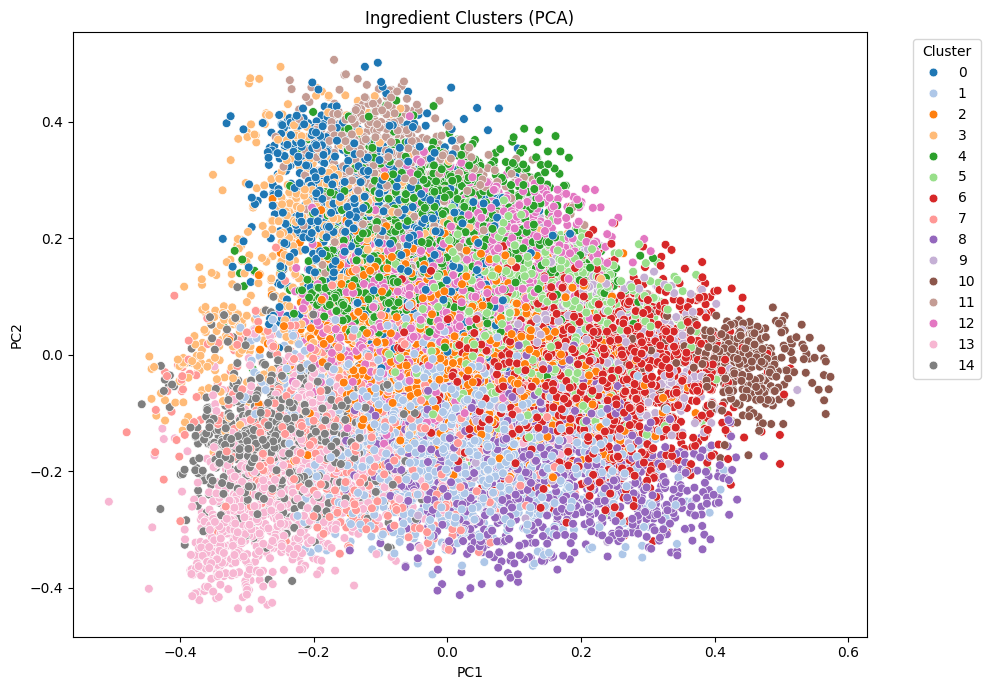

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(ingredient_embeddings)
plt.figure(figsize=(10,7))
sns.scatterplot(x=emb_2d[:,0], y=emb_2d[:,1], hue=labels, palette='tab20', legend='full', s=40)
plt.title('Ingredient Clusters (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
from pyspark.sql.functions import explode as _explode
for c in range(n_clusters):
    print('--- Cluster', c, '---')
    examples = clusters_df.filter(col('cluster') == c).select('ingredient', 'foods').limit(5).collect()
    ingredients_list = [r['ingredient'] for r in examples]
    print('Ingredients:', ', '.join(ingredients_list))
    foods_examples = []
    for r in examples:
        foods_examples.extend(r['foods'] or [])
    print('Example foods:', ', '.join(foods_examples[:5]))
    print()

--- Cluster 0 ---
Ingredients: *not a source of lactose, anhydrous milkfat, butter (cream, butter (pasteurized cream, butter (pasteurized cream [milk]
Example foods: FAT FREE COFFEE CREAMER, SEASONED CRUST SANDWICHES, PHILLY STEAK & CHEESE WITH REDUCED FAT MOZZARELLA CHEESE, PEPPERS, ONIONS & SAUCE IN A SEASONED CRUST SANDWICHES, PHILLY STEAK & CHEESE, HOT POCKETS Philly Steak and Cheese, 8 oz. Sandwich, LIGHT OLD FASHIONED CARAMEL DIP, LIGHT OLD FASHIONED CARAMEL

--- Cluster 1 ---
Ingredients: (dark red kidney beans, (may contain soy lecithin)], *soybeans, *walnuts, acacia gum* for fiber).
Example foods: BBQ BEANS, BBQ, AdvancePierre Fully Cooked Beef Meatballs, 0.50 oz., LEMON CAESAR VINAIGRETTE, LEMON CAESAR, ARTISAN BISTRO, WILD SALMON, SNICKERDOODLE TRUFFLES, SNICKERDOODLE

--- Cluster 2 ---
Ingredients: sugar, (9%) candy coated chocolate flavored chips (sugar, *cinnamon extract, *natural flavor, *natural mint flavor
Example foods: PRINGLES CRISPS SOUR CREAM & ONION 19.68OZ, MARI

In [ ]:
output_dir = f'{path_prefix}/output/ingredient_categories'
if 'hdfs' not in path_prefix:
    os.makedirs(output_dir, exist_ok=True)
for c in range(n_clusters):
    out_df = clusters_df.filter(col('cluster') == c).select('ingredient', _explode('foods').alias('food'))
    out_path = output_dir + f'/cluster_{c}'
    out_df.write.mode('overwrite').csv(out_path, header=True)